In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

In [3]:
data = fits_to_pandas("/Users/honeyeah/Codes/data/APOGEE_ASPCAP/allStarLite-dr17-synspec_rev1.fits")
data = quality_cuts(data)

In [4]:
highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

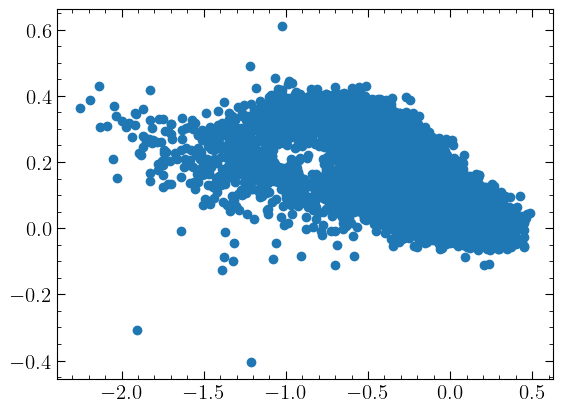

In [5]:
plt.scatter(data['FE_H'], data['MG_FE'])

In [6]:
data['O_H'] = data['O_FE'] + data['FE_H']
data['MG_H'] = data['MG_FE'] + data['FE_H']
data['MN_H'] = data['MN_FE'] + data['FE_H']
data['MN_O'] = data['MN_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']

In [7]:
pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

(-0.1, 0.4)

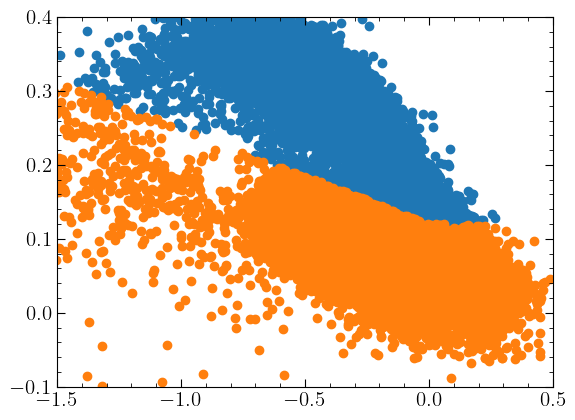

In [8]:
#plt.scatter(low_alpha_data['FE_H'], low_alpha_data['MG_FE'])
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'])
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'])
#plt.scatter(data['FE_H'], data['MG_FE'], color = 'gray', alpha = 0.1, zorder=5)

plt.xlim(-1.5, 0.5)
plt.ylim(-0.1, 0.4)

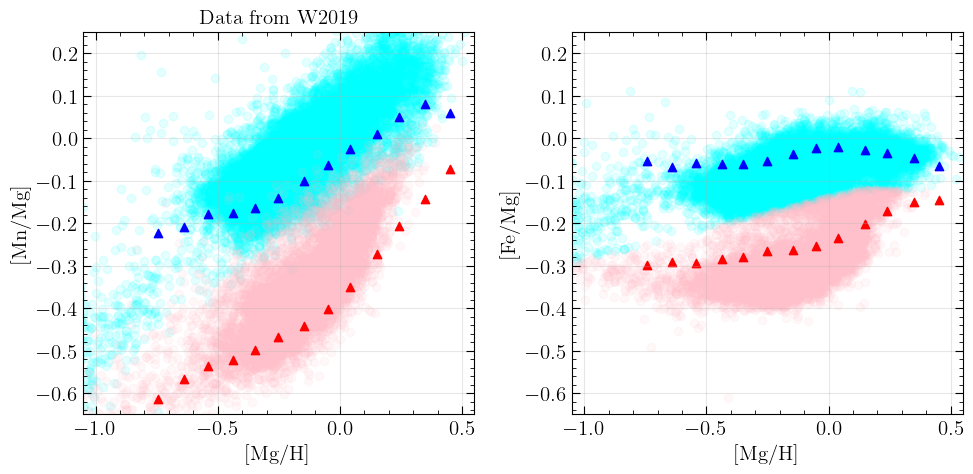

In [9]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
#plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.1, color = 'gray')
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [10]:
t_array = np.linspace(0.0001,14,int(1e3))
tau_sfh_def = 6 #Gyrs
tau_sfh_2 = 15 #Gyrs
m_g_array_exp_def = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_exp_2 = 1 * np.exp(-t_array/tau_sfh_2)
m_g_array_const = np.ones(len(t_array))

gal_def_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_def)
gal_def_2017 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_def, solarvalues_ref="W2017", yields_ref="W2017")

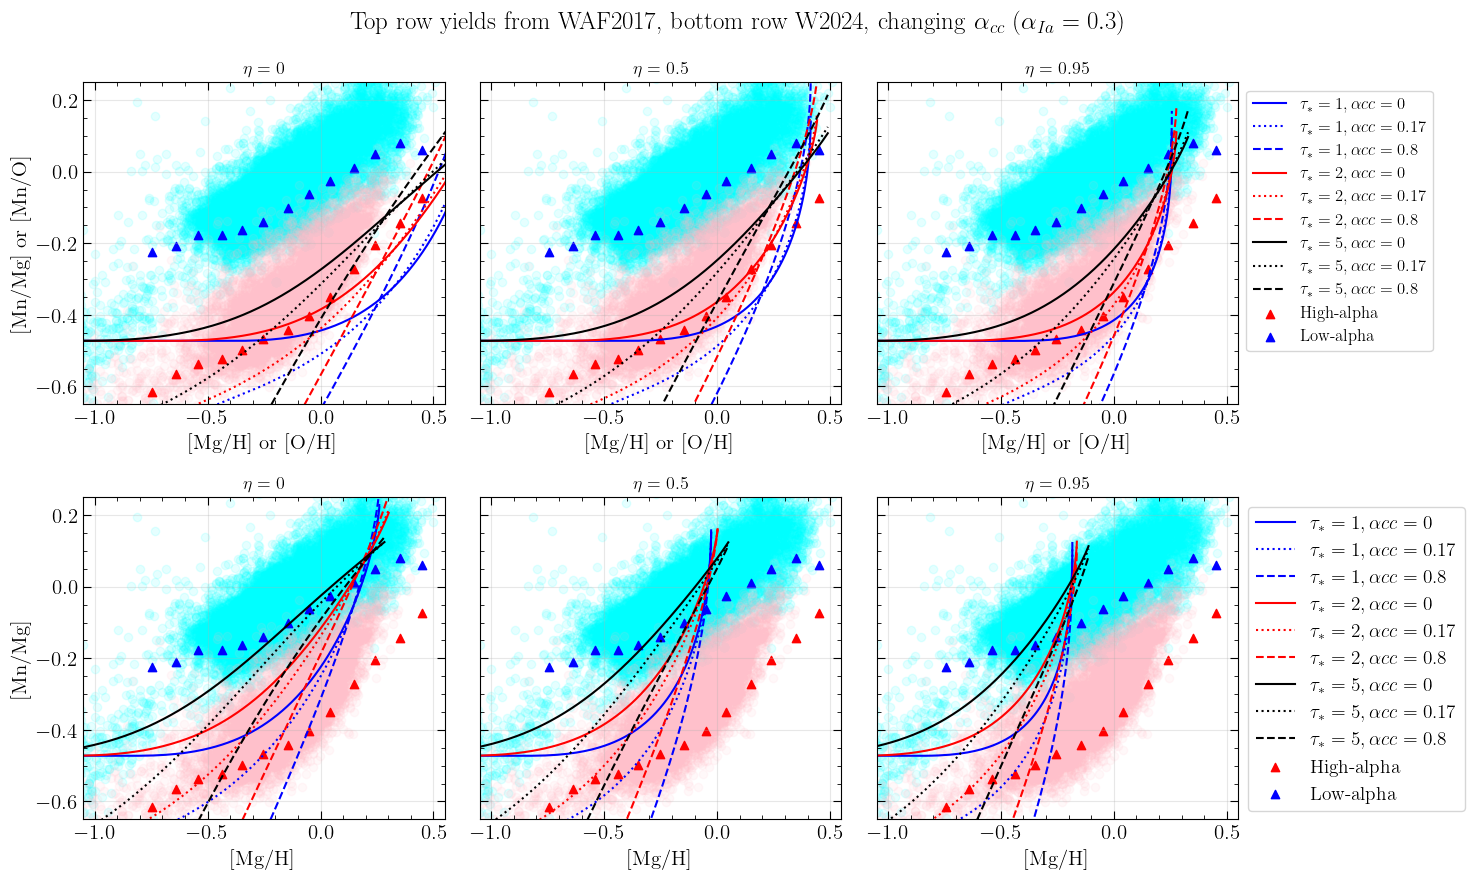

In [11]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 15
tau_Ia = 1.5
linestyles = ['-', ':', '--', '-.']
alpha_ccs = [0, 0.17, 0.8]
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_ccs)):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh),
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2017",
                        yields_ref="W2017",
                        alpha_cc_Mn=alpha_ccs[k]
                    )
            label = rf"$\tau_* = {taustar}, \alpha cc = {alpha_ccs[k]}$"
            ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                    label=label, color=clr, linestyle=linestyles[k])

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        for k, alpha_cc in enumerate(alpha_ccs):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh),
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_cc_Mn=alpha_cc
                        )
            label = rf"$\tau_* = {taustar}, \alpha cc = {alpha_cc}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle(r"Top row yields from WAF2017, bottom row W2024, changing $\alpha_{cc}$ ($\alpha_{Ia} = 0.3$)")
plt.tight_layout()
plt.show()


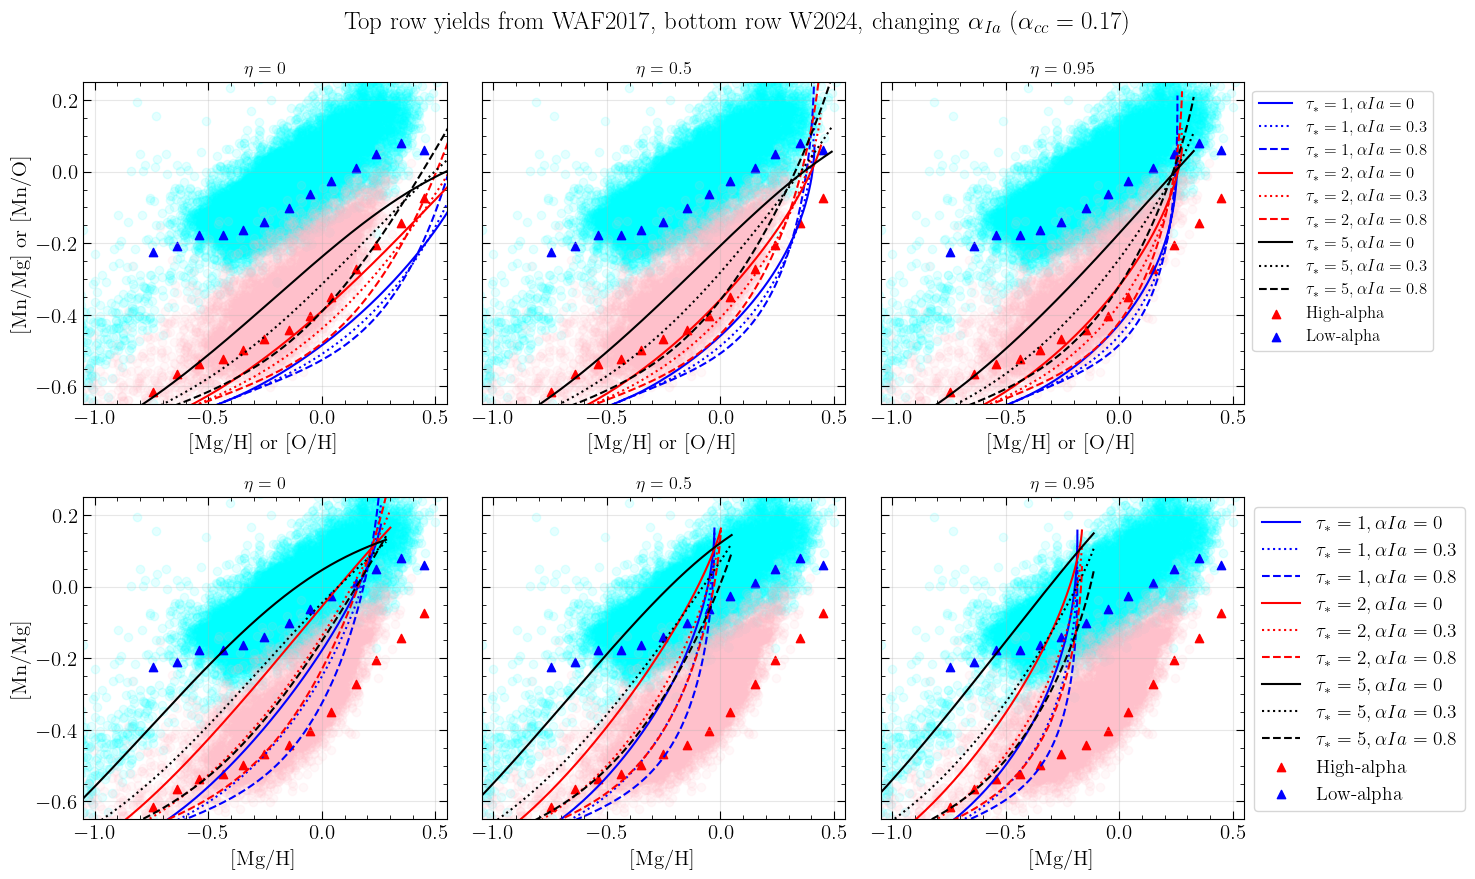

In [12]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-', ':', '--', '-.']
alpha_Ias = [0, 0.3, 0.8]
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_Ias)):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh_2),
                        tau_sfh=tau_sfh_2,
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2017",
                        yields_ref="W2017",
                        alpha_Ia_Mn=alpha_Ias[k]
                    )
            label = rf"$\tau_* = {taustar}, \alpha Ia = {alpha_Ias[k]}$"
            ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                    label=label, color=clr, linestyle=linestyles[k])

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_Ias)):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh_2),
                        tau_sfh=tau_sfh_2,
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_Ia_Mn=alpha_Ias[k]
                        )
            label = rf"$\tau_* = {taustar}, \alpha Ia = {alpha_Ias[k]}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle(r"Top row yields from WAF2017, bottom row W2024, changing $\alpha_{Ia}$ ($\alpha_{cc} = 0.17$)")
plt.tight_layout()

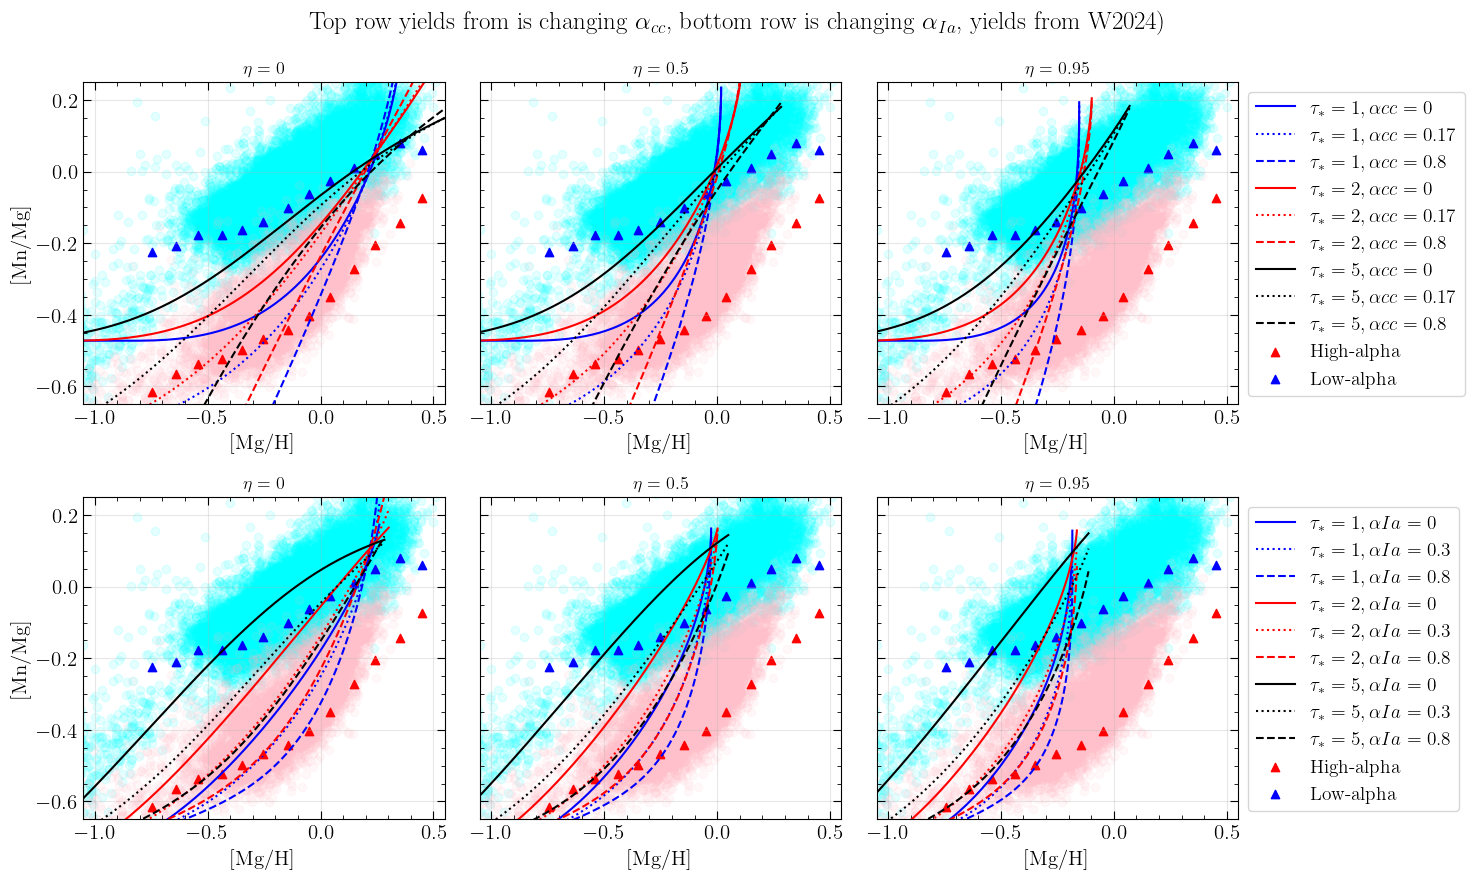

In [74]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-', ':', '--', '-.']
alpha_Ias = [0, 0.3, 0.8]
alpha_ccs = [0, 0.17, 0.8]
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        for k, alpha_cc in enumerate(alpha_ccs):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh),
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_cc_Mn=alpha_cc
                        )
            label = rf"$\tau_* = {taustar}, \alpha cc = {alpha_cc}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)  



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_Ias)):
            clr = colors_2024[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh_2),
                        tau_sfh=tau_sfh_2,
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_Ia_Mn=alpha_Ias[k]
                        )
            label = rf"$\tau_* = {taustar}, \alpha Ia = {alpha_Ias[k]}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
    ax.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle(r"Top row yields from is changing $\alpha_{cc}$, bottom row is changing $\alpha_{Ia}$, yields from W2024)")
plt.tight_layout()

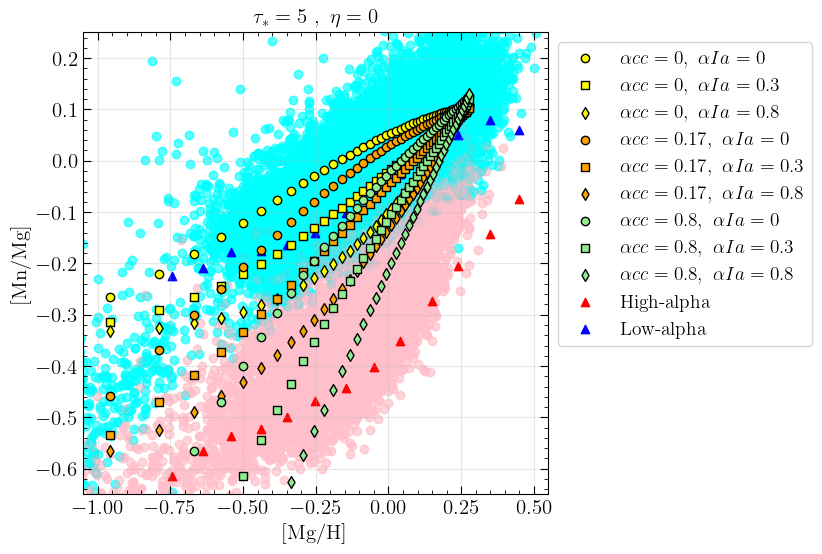

In [83]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
tau_Ia = 1.5
linestyles = ['-', ':', '--', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
alpha_Ias = [0, 0.3, 0.8]
colors = ['yellow', 'orange', 'lightgreen']


plt.figure(figsize=(6,6))
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    color = colors[i]
    for j in range(len(alpha_Ias)):
        alpha_Ia = alpha_Ias[j]
        shape = shapes[j]
        label = rf'$\alpha cc = {alpha_cc}, \ \alpha Ia = {alpha_Ia}$'
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
        plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], facecolors=color, edgecolors = 'black', marker=shape, alpha =1, label = label, zorder=10)
        plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
        plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)

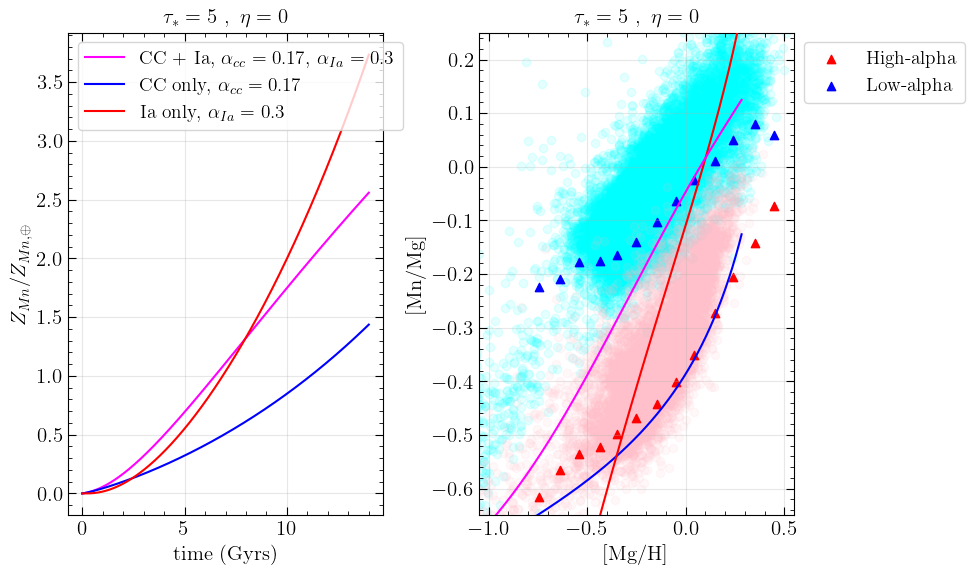

In [53]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)

gal_default = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024", yields_ref="W2024")
gal_no_met_dep = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024", yields_ref="W2024", alpha_cc_Mn=0, alpha_Ia_Mn=0)


plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(gal_default.t, gal_default.compute_z_X()/gal_default.SolarMn, color = 'magenta', label = r'CC + Ia, $\alpha_{cc} = 0.17$, $\alpha_{Ia} = 0.3$')
plt.plot(gal_default.t, gal_default.Z_X_from_cc/gal_default.SolarMn, color = 'blue', label = r'CC only, $\alpha_{cc} = 0.17$')
plt.plot(gal_default.t, gal_default.Z_X_from_Ia/gal_default.SolarMn, color = 'red', label = r'Ia only, $\alpha_{Ia} = 0.3$')
plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.grid(True, alpha=0.3)
plt.xlabel('time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\oplus}$')
plt.legend(loc='upper left', fontsize=14)

plt.subplot(1,2,2)
Mn_H_CC = gal_default.ratio_to_sun(gal_default.Z_X_from_cc, gal_default.SolarMn)
Mn_H_Ia = gal_default.ratio_to_sun(gal_default.Z_X_from_Ia, gal_default.SolarMn)
Mn_O_CC = Mn_H_CC - gal_default.O_H
Mn_O_Ia = Mn_H_Ia - gal_default.O_H
plt.plot(gal_default.O_H[1:], Mn_O_CC[1:], color = 'blue', zorder=10)
plt.plot(gal_default.O_H[1:], Mn_O_Ia[1:], color = 'red', zorder=11)
plt.plot(gal_default.O_H[1:], gal_default.Mn_O[1:], color = 'magenta', zorder=12)

plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)
plt.tight_layout()

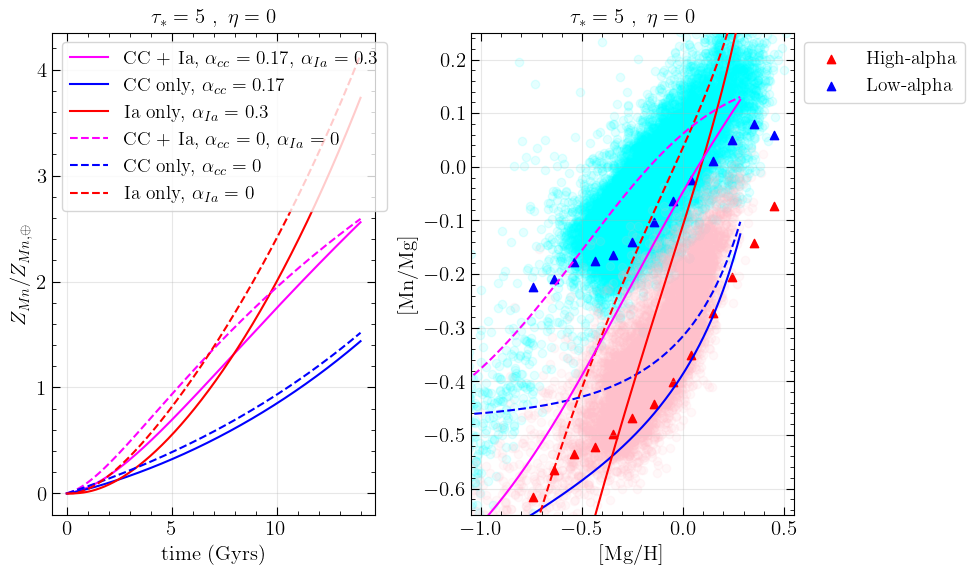

In [56]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)

gal_default = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024", yields_ref="W2024")
gal_no_met_dep = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024", yields_ref="W2024", alpha_cc_Mn=0, alpha_Ia_Mn=0)


plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(gal_default.t, gal_default.compute_z_X()/gal_default.SolarMn, color = 'magenta', label = r'CC + Ia, $\alpha_{cc} = 0.17$, $\alpha_{Ia} = 0.3$')
plt.plot(gal_default.t, gal_default.Z_X_from_cc/gal_default.SolarMn, color = 'blue', label = r'CC only, $\alpha_{cc} = 0.17$')
plt.plot(gal_default.t, gal_default.Z_X_from_Ia/gal_default.SolarMn, color = 'red', label = r'Ia only, $\alpha_{Ia} = 0.3$')

plt.plot(gal_no_met_dep.t, gal_no_met_dep.compute_z_X()/gal_default.SolarMn, color = 'magenta', label = r'CC + Ia, $\alpha_{cc} = 0$, $\alpha_{Ia} = 0$', linestyle='--')
plt.plot(gal_no_met_dep.t, gal_no_met_dep.Z_X_from_cc/gal_default.SolarMn, color = 'blue', label = r'CC only, $\alpha_{cc} = 0$', linestyle='--')
plt.plot(gal_no_met_dep.t, gal_no_met_dep.Z_X_from_Ia/gal_default.SolarMn, color = 'red', label = r'Ia only, $\alpha_{Ia} = 0$', linestyle='--')
plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.grid(True, alpha=0.3)
plt.xlabel('time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\oplus}$')
plt.legend(loc='upper left', fontsize=14)

plt.subplot(1,2,2)

Mn_H_CC_nometdep = gal_no_met_dep.ratio_to_sun(gal_no_met_dep.Z_X_from_cc, gal_no_met_dep.SolarMn)
Mn_H_Ia_nometdep = gal_no_met_dep.ratio_to_sun(gal_no_met_dep.Z_X_from_Ia, gal_no_met_dep.SolarMn)
Mn_O_CC_nometdep = Mn_H_CC_nometdep - gal_no_met_dep.O_H
Mn_O_Ia_nometdep = Mn_H_Ia_nometdep - gal_no_met_dep.O_H

plt.plot(gal_default.O_H[1:], Mn_O_CC[1:], color = 'blue', zorder=10)
plt.plot(gal_default.O_H[1:], Mn_O_Ia[1:], color = 'red', zorder=11)
plt.plot(gal_default.O_H[1:], gal_default.Mn_O[1:], color = 'magenta', zorder=12)

plt.plot(gal_no_met_dep.O_H[1:], Mn_O_CC_nometdep[1:], color = 'blue', zorder=10, linestyle='--')
plt.plot(gal_no_met_dep.O_H[1:], Mn_O_Ia_nometdep[1:], color = 'red', zorder=11, linestyle='--')
plt.plot(gal_no_met_dep.O_H[1:], gal_no_met_dep.Mn_O[1:], color = 'magenta', zorder=12, linestyle='--')

plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)
plt.tight_layout()

Text(0, 0.5, '$Z_{X}/Z_{X,solar}$')

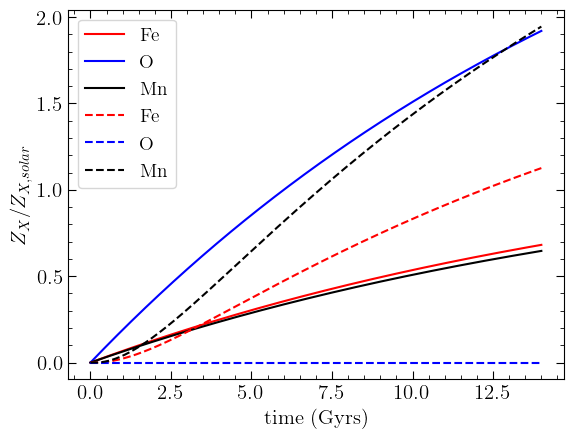

In [38]:
gal_CC_ONLY = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024,CC-ONLY", alpha_cc_Mn=0, alpha_Ia_Mn=0)
gal_IA_ONLY = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024,IA-ONLY", alpha_cc_Mn=0, alpha_Ia_Mn=0)

plt.plot(gal_CC_ONLY.t, gal_CC_ONLY.compute_z_Fe()/gal_CC_ONLY.SolarFe, color = 'red', label = 'Fe')
plt.plot(gal_CC_ONLY.t, gal_CC_ONLY.compute_z_O()/gal_CC_ONLY.SolarO, color = 'blue', label = 'O')
plt.plot(gal_CC_ONLY.t, gal_CC_ONLY.compute_z_X(element='Mn')/gal_CC_ONLY.SolarMn, color = 'black', label = 'Mn')

plt.plot(gal_IA_ONLY.t, gal_IA_ONLY.compute_z_Fe()/gal_CC_ONLY.SolarFe, color = 'red', label = 'Fe', linestyle='--')
plt.plot(gal_IA_ONLY.t, gal_IA_ONLY.compute_z_O()/gal_CC_ONLY.SolarO, color = 'blue', label = 'O', linestyle='--')
plt.plot(gal_IA_ONLY.t, gal_IA_ONLY.compute_z_X(element='Mn')/gal_CC_ONLY.SolarMn, color = 'black', label = 'Mn', linestyle='--')

plt.legend()
plt.xlabel('time (Gyrs)')
plt.ylabel(r'$Z_{X}/Z_{X,solar}$')

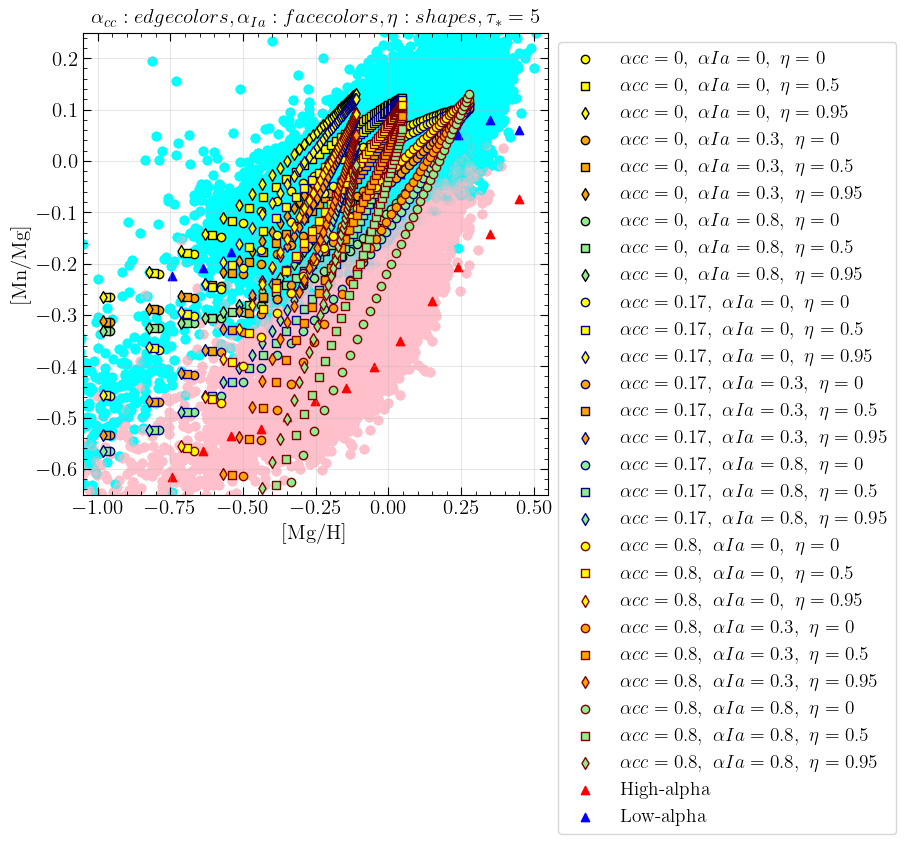

In [79]:
etas = [0, 0.5, 0.95]
#tau_stars = [1, 2, 5]
tau_stars = [5]
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
linestyles = ['-', ':', '--', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
#alpha_ccs = [0.17]
alpha_Ias = [0, 0.3, 0.8]
#alpha_Ias = [0.3]
#colors = ['black', 'magenta', 'green']
colors = ['yellow', 'orange', 'lightgreen']
#edgecolors = ['blue', 'orange', 'maroon']
edgecolors = ['black', 'navy', 'maroon']


plt.figure(figsize=(6,6))
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    edgecolor=edgecolors[i]
    for j in range(len(alpha_Ias)):
        alpha_Ia = alpha_Ias[j]
        facecolor = colors[j]
        for k in range(len(etas)):
            eta = etas[k]
            shape = shapes[k]
            for l in range(len(tau_stars)):
                taustar=tau_stars[l]
                label = rf'$\alpha cc = {alpha_cc}, \ \alpha Ia = {alpha_Ia}, \ \eta = {eta}$'
                gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
                plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], facecolors=facecolor, edgecolors = edgecolor, marker=shape, alpha =1, label = label, zorder=10)
                plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
                plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(r'$\alpha_{cc}: edgecolors, \alpha_{Ia}: facecolors, \eta: shapes, \tau_* = 5$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)

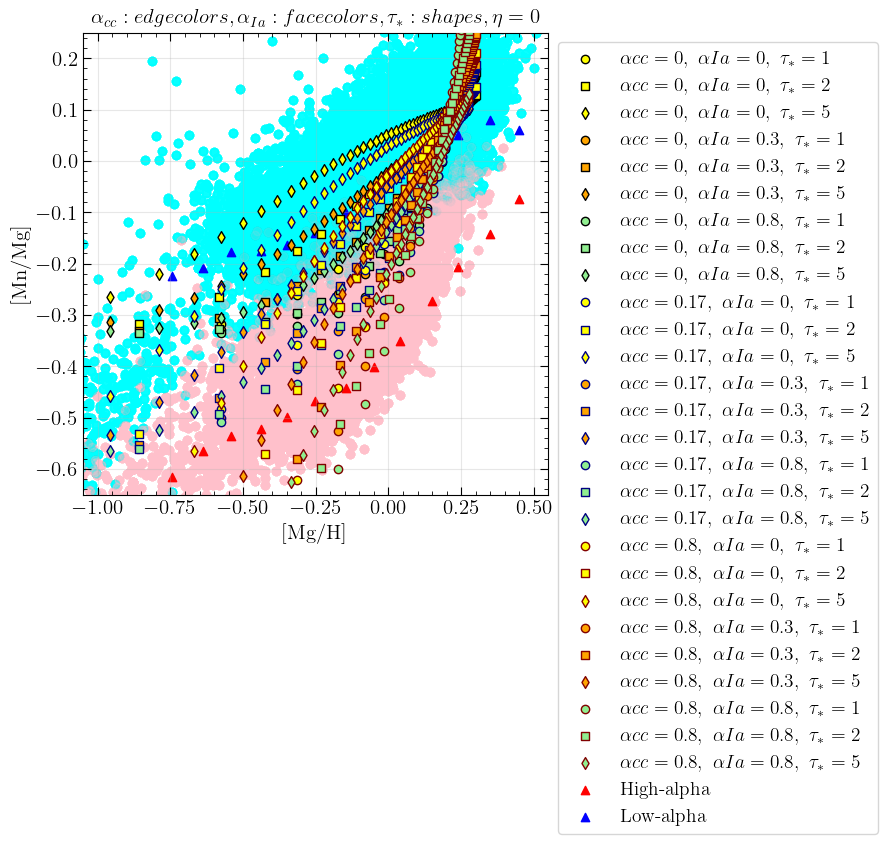

In [80]:
#etas = [0, 0.5, 0.95]
etas = [0]
tau_stars = [1, 2, 5]
#tau_stars = [2]
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
linestyles = ['-', ':', '--', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
#alpha_ccs = [0.17]
alpha_Ias = [0, 0.3, 0.8]
#alpha_Ias = [0.3]
colors = ['yellow', 'orange', 'lightgreen']
edgecolors = ['black', 'navy', 'maroon']


plt.figure(figsize=(6,6))
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    edgecolor=edgecolors[i]
    for j in range(len(alpha_Ias)):
        alpha_Ia = alpha_Ias[j]
        facecolor = colors[j]
        for k in range(len(etas)):
            eta = etas[k]
            for l in range(len(tau_stars)):
                shape = shapes[l]
                tau_star=tau_stars[l]
                label = rf'$\alpha cc = {alpha_cc}, \ \alpha Ia = {alpha_Ia}, \ \tau_* = {tau_star}$'
                gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=tau_star, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
                plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], facecolors=facecolor, edgecolors = edgecolor, marker=shape, alpha =1, label = label, zorder=10)
                plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
                plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(r'$\alpha_{cc}: edgecolors, \alpha_{Ia}: facecolors, \tau_*: shapes, \eta = 0$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)